# 02 - Exploratory Data Analysis

Uses the cleaned dataset from `01_data_cleaning.ipynb` to look at how credit risk
relates to loan and applicant characteristics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("../data/processed/german_credit_processed.csv")
df.shape

(1000, 23)

## 1. Credit risk distribution

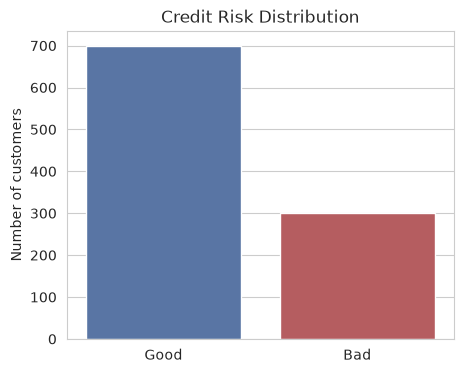

risk
Good    70.0
Bad     30.0
Name: proportion, dtype: float64

In [2]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="risk", hue="risk", order=["Good", "Bad"], legend=False,
              palette={"Good": "#4C72B0", "Bad": "#C44E52"})
plt.title("Credit Risk Distribution")
plt.xlabel("")
plt.ylabel("Number of customers")
plt.show()

df["risk"].value_counts(normalize=True).round(3) * 100

**700 Good (70%) vs 300 Bad (30%).** Imbalanced, as expected for a lending
portfolio - most loans do get repaid - but it means we'll need to pick evaluation
metrics carefully later instead of leaning on accuracy alone.

## 2. Loan amount distribution

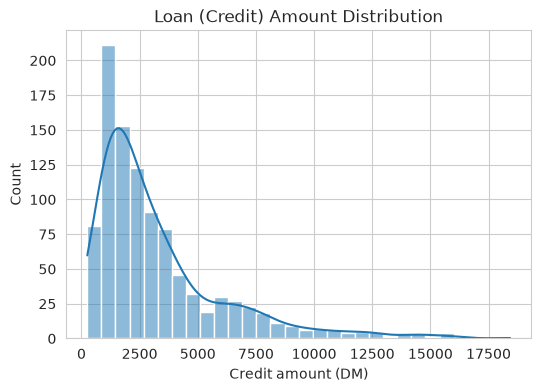

count     1000.0
mean      3271.0
std       2823.0
min        250.0
25%       1366.0
50%       2320.0
75%       3972.0
max      18424.0
Name: credit_amount, dtype: float64

In [3]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="credit_amount", bins=30, kde=True)
plt.title("Loan (Credit) Amount Distribution")
plt.xlabel("Credit amount (DM)")
plt.show()

df["credit_amount"].describe().round(0)

Right-skewed: median loan is about 2,320 DM, but a handful of much larger loans
(up toward 18,000 DM) pull the mean up to about 3,271 DM. This skew is part of why
we scale this feature before it goes into logistic regression.

## 3. Loan duration distribution

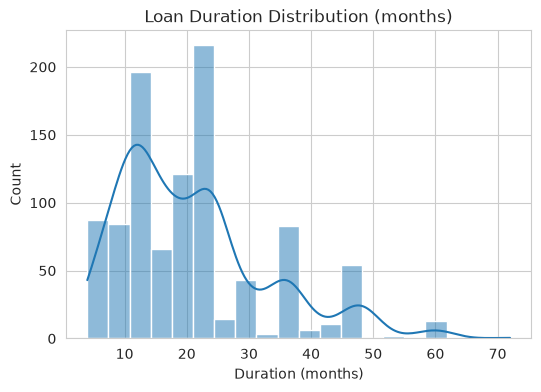

count    1000.0
mean       20.9
std        12.1
min         4.0
25%        12.0
50%        18.0
75%        24.0
max        72.0
Name: duration_months, dtype: float64

In [4]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="duration_months", bins=20, kde=True)
plt.title("Loan Duration Distribution (months)")
plt.xlabel("Duration (months)")
plt.show()

df["duration_months"].describe().round(1)

Durations cluster around common loan terms (12, 24, 36, 48 months), from 4 to 72
months, median 18. Same right-skewed shape as credit amount.

## 4. Risk vs credit history

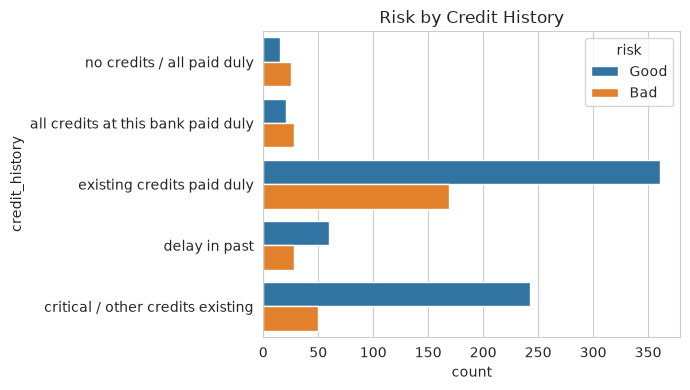

credit_history
no credits / all paid duly            62.5
all credits at this bank paid duly    57.1
existing credits paid duly            31.9
delay in past                         31.8
critical / other credits existing     17.1
Name: risk, dtype: float64

In [5]:
order = (df.groupby("credit_history")["risk"]
         .apply(lambda s: (s == "Bad").mean())
         .sort_values(ascending=False).index)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, y="credit_history", hue="risk", order=order)
plt.title("Risk by Credit History")
plt.tight_layout()
plt.show()

(df.groupby("credit_history")["risk"]
   .apply(lambda s: (s == "Bad").mean() * 100)
   .sort_values(ascending=False).round(1))

This is the most counter-intuitive result in the whole analysis. Applicants with
**"no credits taken / all paid duly"** have the *highest* bad-risk rate (62.5%),
while applicants with a **"critical account / other credits existing"** have the
*lowest* (17.1%).

That looks backwards at first glance, but it's a known quirk of this dataset:
people with more credit history (even a rocky one) have given the bank more to go
on, and the "critical account" group here is likely a pool that already survived
some earlier screening. People with *no* history are more of an unknown. Good
reminder that **correlation isn't causation** - having a critical account doesn't
cause good repayment behavior.

## 5. Risk vs employment length

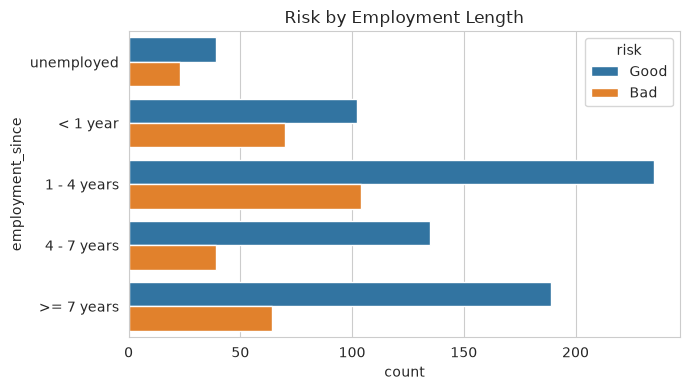

employment_since
unemployed     37.1
< 1 year       40.7
1 - 4 years    30.7
4 - 7 years    22.4
>= 7 years     25.3
Name: risk, dtype: float64

In [6]:
order5 = ["unemployed", "< 1 year", "1 - 4 years", "4 - 7 years", ">= 7 years"]
plt.figure(figsize=(7, 4))
sns.countplot(data=df, y="employment_since", hue="risk", order=order5)
plt.title("Risk by Employment Length")
plt.tight_layout()
plt.show()

(df.groupby("employment_since")["risk"]
   .apply(lambda s: (s == "Bad").mean() * 100)
   .reindex(order5).round(1))

More intuitive here: bad-risk rate is highest for applicants employed **less than
1 year (40.7%)** or **unemployed (37.1%)**, and lowest for **4-7 years employed
(22.4%)**. Employment stability reads as a pretty straightforward risk signal.

## 6. Risk vs loan purpose

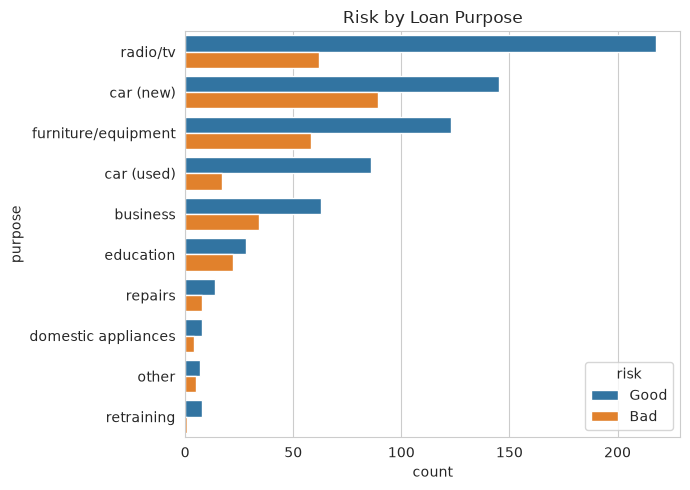

,num_customers,bad_risk_pct
purpose,,
education,50,44.0
other,12,41.7
car (new),234,38.0
repairs,22,36.4
business,97,35.1
domestic appliances,12,33.3
furniture/equipment,181,32.0
radio/tv,280,22.1
car (used),103,16.5


In [7]:
order6 = df["purpose"].value_counts().index
plt.figure(figsize=(7, 5))
sns.countplot(data=df, y="purpose", hue="risk", order=order6)
plt.title("Risk by Loan Purpose")
plt.tight_layout()
plt.show()

purpose_summary = df.groupby("purpose").agg(
    num_customers=("risk", "size"),
    bad_risk_pct=("risk", lambda s: round((s == "Bad").mean() * 100, 1))
).sort_values("bad_risk_pct", ascending=False)
purpose_summary

Highest bad-risk rates: **education (44.0%)**, **car - new (38.0%)**, **repairs
(36.4%)**. Lowest: **car - used (16.5%)**, **retraining (11.1%)**. A few purposes
(domestic appliances, other, retraining) have under 15 customers, so treat those
specific rates as directional rather than solid.

## 7. Risk vs age group

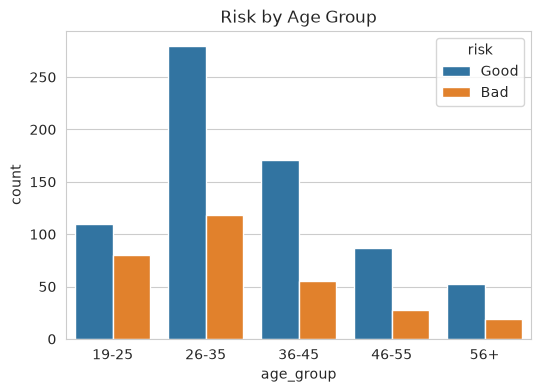

age_group
19-25    42.1
26-35    29.6
36-45    24.3
46-55    24.3
56+      26.8
Name: risk, dtype: float64

In [8]:
age_order = ["19-25", "26-35", "36-45", "46-55", "56+"]
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="age_group", hue="risk", order=age_order)
plt.title("Risk by Age Group")
plt.show()

(df.groupby("age_group", observed=True)["risk"]
   .apply(lambda s: (s == "Bad").mean() * 100)
   .reindex(age_order).round(1))

Youngest applicants (19-25) stand out with a **42.1% bad-risk rate**, clearly
above every other age group (24-30%). Risk eases with age before a slight uptick
for 56+, though that group is also the smallest (71 people), so that uptick is
less solid than the clear pattern for young applicants.

## 8. Correlation between numeric features

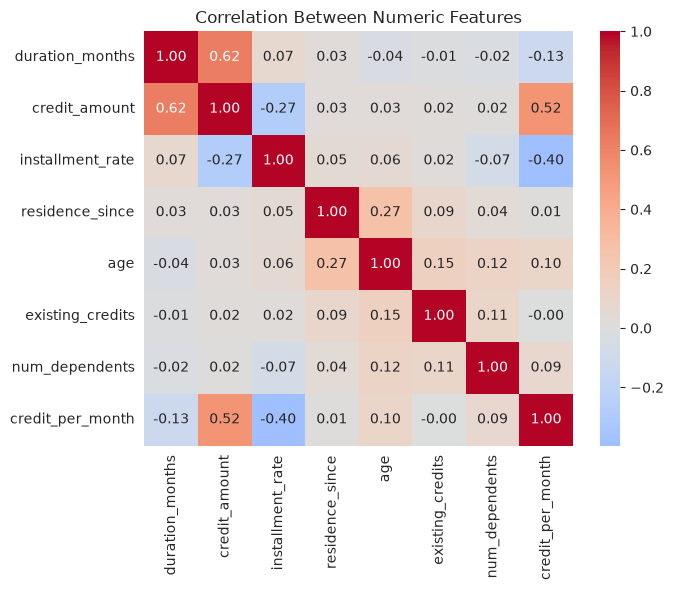

In [9]:
num_cols = ["duration_months", "credit_amount", "installment_rate", "residence_since",
            "age", "existing_credits", "num_dependents", "credit_per_month"]

plt.figure(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

Nothing is strongly correlated, which is good news for logistic regression later
(less risk of multicollinearity). The two relationships worth a mention:

- **`duration_months` and `credit_amount` (0.62)** - bigger loans tend to run
  longer, which makes sense since duration is one lever for keeping monthly
  payments manageable on a larger loan.
- **`credit_per_month` and `installment_rate` (-0.40)** - partly mechanical, since
  `credit_per_month` is derived from amount and duration, but the two still clearly
  move together.

## EDA summary - key takeaways

- 70% Good risk / 30% Bad risk - imbalanced.
- Loan amount and duration are both right-skewed with a handful of large/long outliers.
- **Credit history has the strongest - but most counter-intuitive - relationship
  with risk.** Worth checking group sizes and thinking about *why* before treating
  any pattern as causal.
- **Checking account status, employment length, and age** all show more intuitive,
  steadier relationships with risk and make good candidates for business-friendly
  segments.
- Numeric features aren't strongly collinear, which supports using a fairly simple
  logistic regression as the model for this project.